# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
from cases.open_space.ngsolve_geometries import AnularDomain

R = 1.
r = 0.2


lc = 2.

mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=lc, lc=lc)


In [2]:
mesh.n_triangles

106

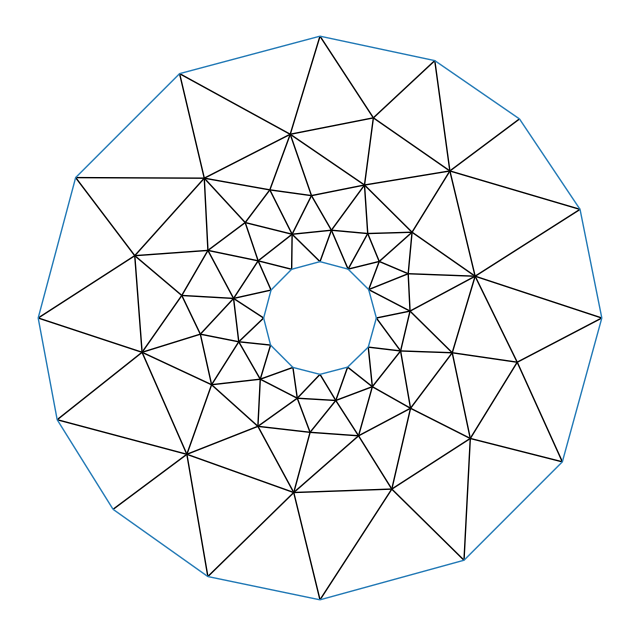

In [3]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [4]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [5]:
mesh.curve_boundary(Boundaries.SIGMA, radius=R)
mesh.curve_boundary(Boundaries.D_OMEGA, radius=r)

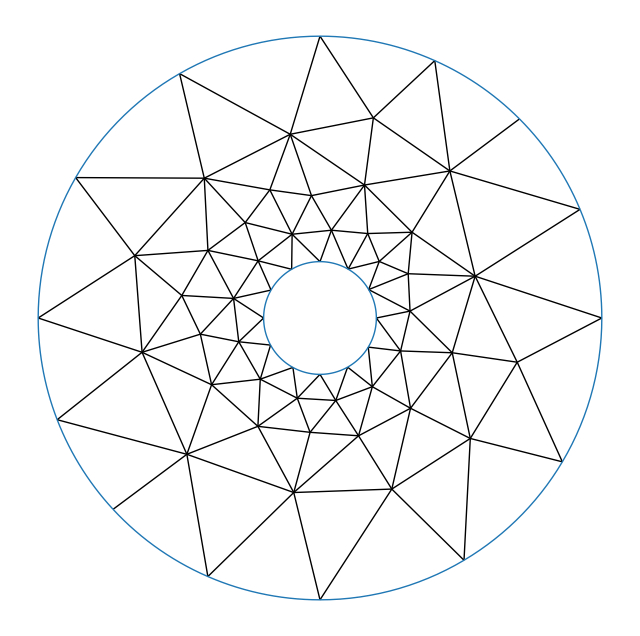

In [6]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [7]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [8]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=1.)
# boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}


Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [9]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [10]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [11]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5

# numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [12]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
k = 8.0
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [13]:
basis.N_DOF

1484

In [14]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [15]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [16]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [17]:
A = P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 14/14 [00:00<00:00, 23.82edge/s]


region: d_Omega


Interior: 100%|██████████| 146/146 [00:00<00:00, 1236.43edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 14/14 [01:11<00:00,  5.11s/edge]


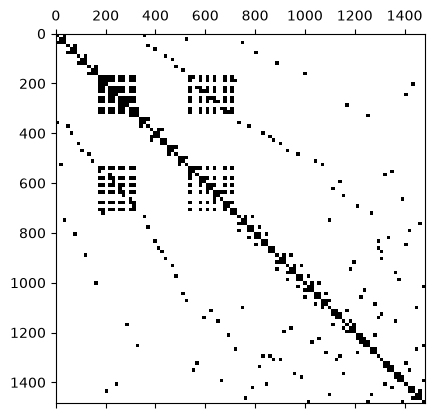

In [18]:
import matplotlib.pyplot as plt 
plt.spy(A.toarray())

In [19]:
b = P.assemble_RHS()

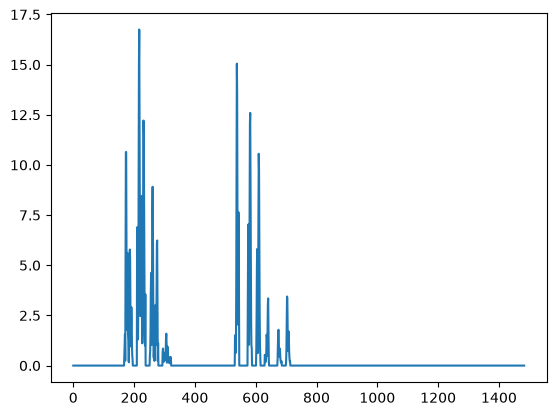

In [20]:
import numpy as np 
plt.plot(np.abs(b))

In [21]:
P.solve()

In [22]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[ 6.90855892e+03+9.81407025e+03j,  2.79736077e+03-1.23956909e+04j,
        -1.11718503e+04+7.97154887e+03j, ...,
        -1.03799475e+04+8.09720219e+03j,  1.11671595e+04-4.82254832e+03j,
        -1.16025740e+04-2.02749746e+03j],
       [ 9.80816605e+03+1.03292979e+04j, -6.83188641e+02-1.45959804e+04j,
        -6.06787225e+03+1.37636470e+04j, ...,
        -2.88213591e+03+1.36996856e+04j,  9.81929364e+03-9.84443237e+03j,
        -1.39937384e+04+1.69001269e+02j],
       [ 7.68712555e+03-7.72027434e+03j, -1.06865691e+04-1.35856418e+03j,
         7.14892371e+03+7.92619299e+03j, ...,
         1.10182062e+04+2.08857563e+03j, -8.89265104e+03-6.67735249e+03j,
         1.68188985e+03+1.08847419e+04j],
       ...,
       [-3.53373286e+00+8.16097529e-01j,  8.00898097e-01+3.54332547e+00j,
         2.76038039e+00-2.52534284e+00j, ...,
         8.92531843e-01+4.19891602e+00j,  3.43515300e+00-2.02470220e+00j,
        -1.60216746e+00-3.37189365e+00j],
       [-7.19477269e-01-7.26147098e+00j, -7.

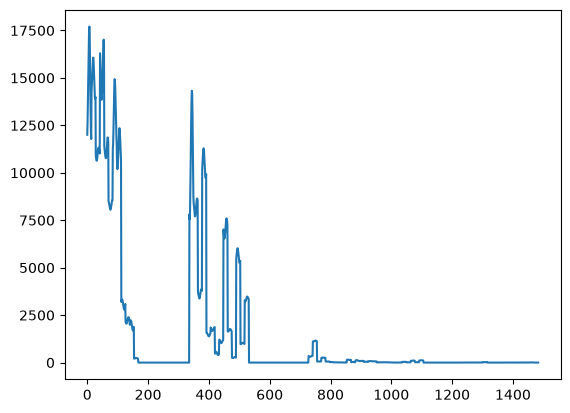

In [23]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

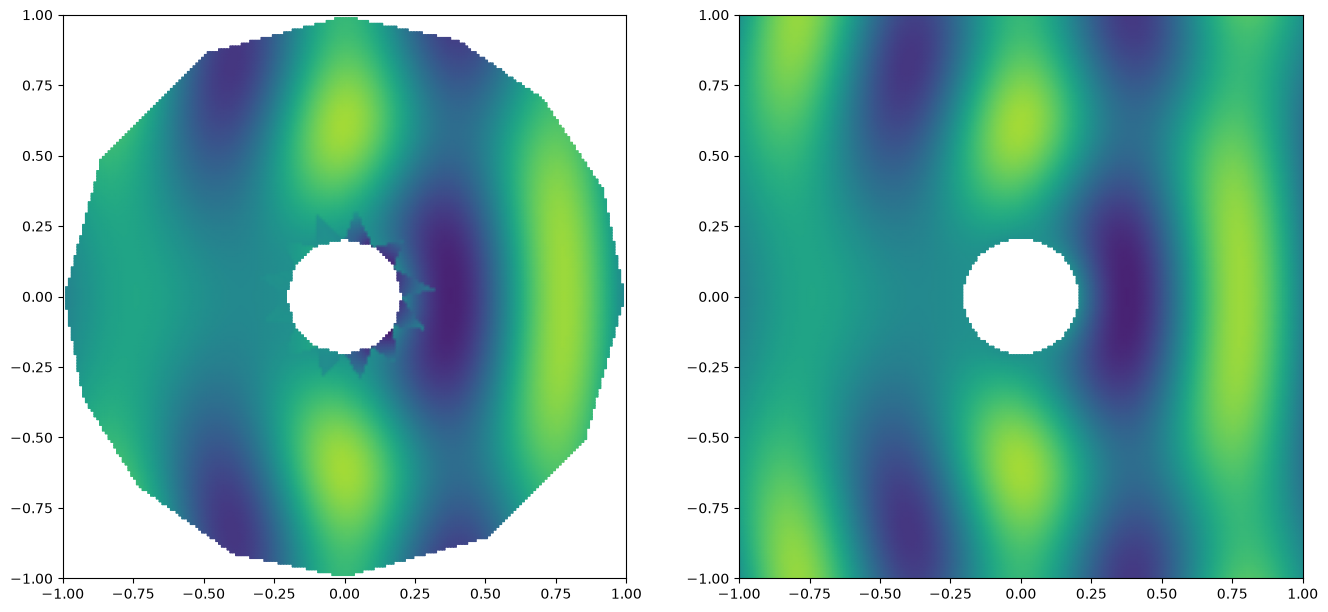

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from cases.open_space.exact import CircularDirichlet

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U_s = CircularDirichlet(X, Y, R=r, k=k, theta_inc=np.pi)
U_inc = np.exp(-1j*k*X)
U = U_s + U_inc
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), vmin=-2, vmax=2, shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), vmin=-2, vmax=2, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

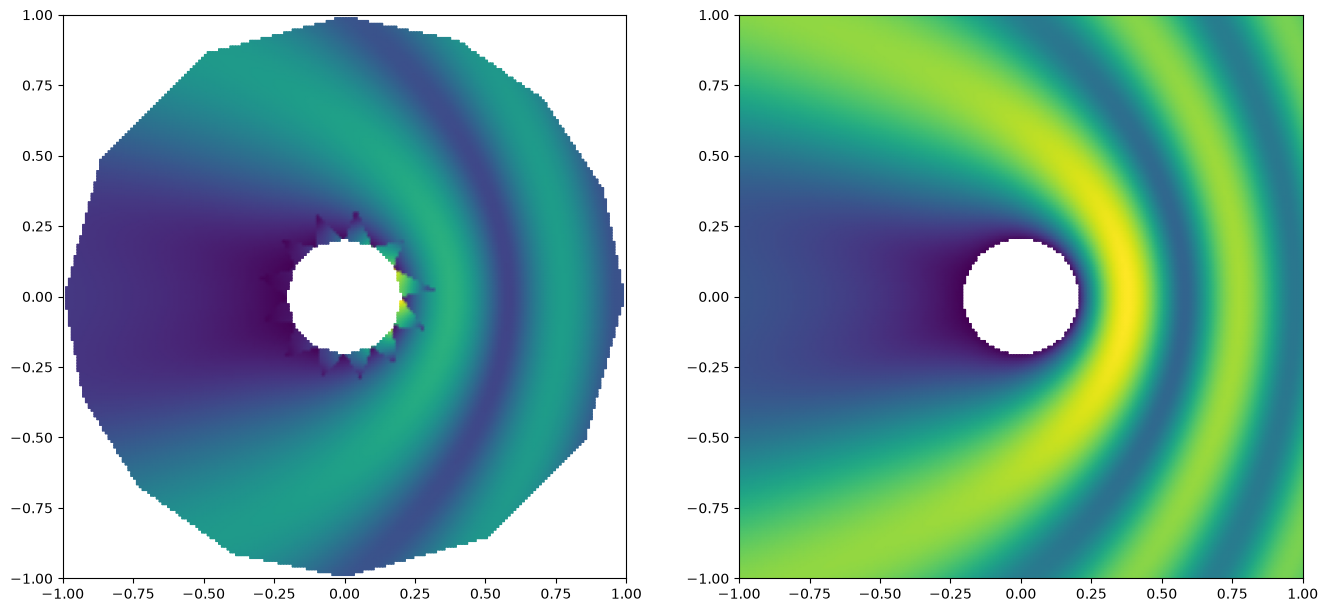

In [25]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.abs(U), shading="gouraud")
ax[1].axis('square')


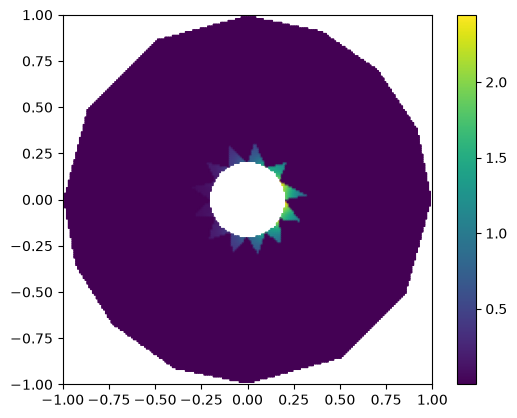

In [26]:
plt.pcolormesh(X, Y, np.abs(U - U_h), shading="gouraud")
plt.axis("square")
plt.colorbar()